In [15]:
import numpy as np
from scipy.integrate import solve_ivp
from tqdm import tqdm

# -----------------------------
# Parameters and vector field
# -----------------------------
beta_1 = 1.0
beta_2 = 0.84
rho = 0.048

kappa_prime = 0.8544
kappa_cr_1 = beta_1 - 1.0
kappa_cr_2 = (
    kappa_cr_1
    + rho * (2 * beta_1 + (beta_2 - 1) * (2 + rho))
    + np.sqrt(
        4 * rho**2 * (kappa_cr_1 + beta_2)
        + (kappa_cr_1 + rho**2 * (beta_2 - 1))**2
    )
) / (2 * (1 + rho))

kappa = kappa_cr_2 * kappa_prime

v_0 = 1.0

def f(t, X):
    """Base vector field: X = (x, y, z)."""
    x, y, z = X
    ex = np.exp(x)

    dx = (
        -kappa * (ex - v_0)
        + ex * (x * (beta_1 - 1.0) + y - z)
        + rho * ex * (beta_2 * x + z)
    )
    dy = -kappa * (ex - v_0)
    dz = -rho * ex * (beta_2 * x + z)
    return np.array([dx, dy, dz], dtype=float)

def jacobian(X):
    """Jacobian J(x,y,z) of f at X."""
    x, y, z = X
    ex = np.exp(x)

    # f1
    g = x * (beta_1 - 1.0) + y - z
    h = beta_2 * x + z

    f1x = ex * (
        -kappa
        + (beta_1 - 1.0)
        + g
        + rho * beta_2
        + rho * h
    )
    f1y = ex
    f1z = ex * (-1.0 + rho)

    # f2
    f2x = -kappa * ex
    f2y = 0.0
    f2z = 0.0

    # f3
    f3x = -rho * ex * (beta_2 + h)
    f3y = 0.0
    f3z = -rho * ex

    J = np.array([
        [f1x, f1y, f1z],
        [f2x, f2y, f2z],
        [f3x, f3y, f3z],
    ], dtype=float)
    return J

# -----------------------------------------
# Extended system: base + variational flow
# -----------------------------------------
def extended_system(t, Y):
    """
    Y = [x, y, z, Phi_flat]
    where Phi is 3x3 fundamental matrix of variational equations.
    """
    X = Y[:3]
    Phi = Y[3:].reshape(3, 3)

    dXdt = f(t, X)
    J = jacobian(X)
    dPhidt = J @ Phi

    return np.concatenate([dXdt, dPhidt.ravel()])


# -----------------------------------------
# Lyapunov exponent computation (Benettin)
# -----------------------------------------
def lyapunov_exponents(
    X0,
    t_max=5000.0,
    dt=0.5,
    t_transient=1000.0,
):
    """
    Compute Lyapunov exponents via QR-based Benettin algorithm.
    """
    # Initial fundamental matrix = identity
    Phi0 = np.eye(3)
    Y0 = np.concatenate([X0, Phi0.ravel()])

    # Time grid for re-orthonormalisation steps
    n_steps = int(t_max / dt)
    times = np.linspace(0.0, t_max, n_steps + 1)

    # Accumulators for log norms
    le_sum = np.zeros(3)
    count = 0

    # Current state
    Y_curr = Y0
    t_curr = 0.0

    le_history = []

    for i in tqdm(range(1, len(times))):
        t_next = times[i]

        # Integrate from t_curr to t_next
        sol = solve_ivp(
            extended_system,
            (t_curr, t_next),
            Y_curr,
            method="RK45",
            rtol=1e-8,
            atol=1e-10,
        )
        Y_curr = sol.y[:, -1]
        t_curr = t_next

        # After transient, start accumulating exponents
        if t_curr > t_transient:
            X = Y_curr[:3]
            Phi = Y_curr[3:].reshape(3, 3)

            # QR decomposition for re-orthonormalisation
            Q, R = np.linalg.qr(Phi)

            # Diagonal of R gives stretching factors over this interval
            diagR = np.diag(R)
            # Avoid log(0)
            #diagR[diagR == 0] = 1e-30

            le_sum += np.log(np.abs(diagR))
            count += 1

            # Reset Phi to Q (orthonormal basis)
            Y_curr[3:] = Q.ravel()

            le_history.append(list(le_sum).copy() / (t_curr-t_transient))



    # Average over total time after transient
    total_time = (t_max - t_transient)
    # Each step corresponds to dt
    le = le_sum / total_time
    return le, le_history

In [16]:
X0 = np.array([0.1, 0.0, 0.0], dtype=float)

les, le_hist = lyapunov_exponents(
    X0,
    t_max=5000.0,
    dt=0.5,
    t_transient=1000.0,
)
print("Lyapunov exponents:", les)

100%|██████████| 10000/10000 [00:04<00:00, 2265.90it/s]

Lyapunov exponents: [ 0.00695465  0.00069925 -0.08532272]


<Axes: >

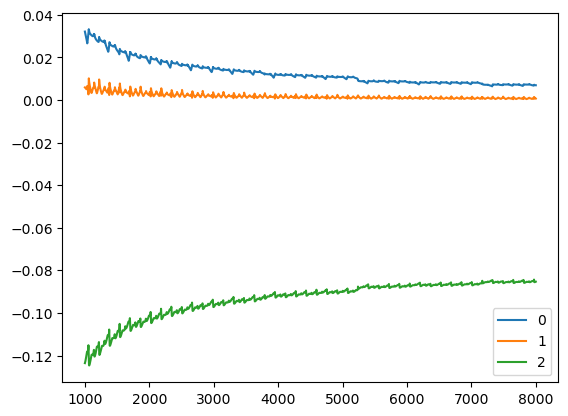

In [18]:
import pandas as pd

pd.DataFrame(np.array(le_hist))[1000:].plot()

In [4]:
## lyapunov dimension

2 + (les[0] + les[1]) / abs(les[2])

np.float64(2.089705357298959)